In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [2]:
print("Num physical GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Num logical GPUs Available: ", len(tf.config.list_logical_devices('GPU')))

Num physical GPUs Available:  1
Num logical GPUs Available:  1


If a GPU is detected, TensorFlow typically uses it automatically. You can also explicitly list all physical devices (CPU and GPU) and set up memory growth if needed to prevent TensorFlow from allocating all available GPU memory at once.

In [3]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        # Enable memory growth for all GPUs
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(physical_devices), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found.")

Physical devices cannot be modified after being initialized


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After setting up, TensorFlow will automatically utilize the GPU if available. You can verify this by running a simple TensorFlow operation and checking the device it runs on.

In [6]:
DATASET_DIR = "/content/drive/MyDrive/Solar_Panel_Dataset"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [8]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [9]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [10]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [11]:
num_classes

6

## Base Model (CNN2D)

In [12]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 10

In [16]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 301s 13s/step - accuracy: 0.2895 - loss: 2.2357 - val_accuracy: 0.4181 - val_loss: 1.5875
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - accuracy: 0.4110 - loss: 1.4797 - val_accuracy: 0.4294 - val_loss: 1.4603
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 549ms/step - accuracy: 0.5494 - loss: 1.2244 - val_accuracy: 0.4689 - val_loss: 1.2978
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - accuracy: 0.6610 - loss: 0.9513 - val_accuracy: 0.6158 - val_loss: 1.1867
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 489ms/step - accuracy: 0.7825 - loss: 0.6570 - val_accuracy: 0.5367 - val_loss: 1.2995
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 500ms/step - accuracy: 0.8136 - loss: 0.5758 - val_accuracy: 0.5763 - val_loss: 1.4390
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 578ms/step - accuracy: 0.9096 - loss: 0.2716 - val_accuracy: 0.5819 - val_loss: 1.5715
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 511ms/step - accuracy: 0.9548 - loss: 0.1403 - val_accur

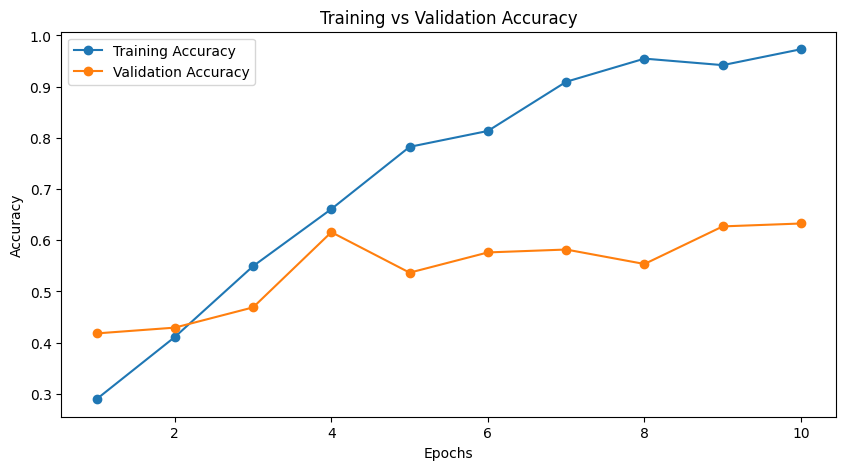

In [17]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 422ms/step - accuracy: 0.9901 - loss: 0.0616 - val_accuracy: 0.6158 - val_loss: 1.6859
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 510ms/step - accuracy: 0.9887 - loss: 0.0700 - val_accuracy: 0.6667 - val_loss: 1.6375
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 510ms/step - accuracy: 0.9944 - loss: 0.0289 - val_accuracy: 0.6667 - val_loss: 1.8562
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 522ms/step - accuracy: 0.9958 - loss: 0.0493 - val_accuracy: 0.6271 - val_loss: 1.5751
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 565ms/step - accuracy: 0.9944 - loss: 0.0269 - val_accuracy: 0.6384 - val_loss: 1.9212
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 447ms/step - accuracy: 0.9958 - loss: 0.0297 - val_accuracy: 0.6384 - val_loss: 1.7594
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 0.9944 - loss: 0.0317 - val_accuracy: 0.6723 - val_loss: 1.8001
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 504ms/step - accuracy: 0.9944 - loss: 0.0307 - val_accu

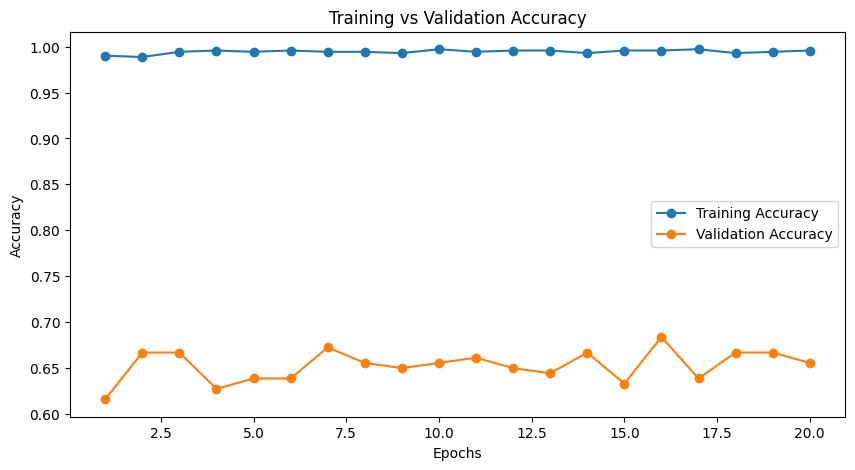

In [19]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Solve the Overfitting problem

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [21]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch,lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_schedule = LearningRateScheduler(scheduler)

In [22]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [23]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,630 (42.61 MB)

 Trainable params: 11,170,182 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
EPOCHS = 10

In [26]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 745ms/step - accuracy: 0.3686 - loss: 11.6748 - val_accuracy: 0.2938 - val_loss: 7.8256
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 580ms/step - accuracy: 0.4379 - loss: 1.5228 - val_accuracy: 0.0960 - val_loss: 69.9283
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 465ms/step - accuracy: 0.5607 - loss: 1.2451 - val_accuracy: 0.0904 - val_loss: 100.2248
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 520ms/step - accuracy: 0.6186 - loss: 1.0386 - val_accuracy: 0.0904 - val_loss: 103.6770
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step - accuracy: 0.6737 - loss: 0.8623 - val_accuracy: 0.0904 - val_loss: 78.6550
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 521ms/step - accuracy: 0.7288 - loss: 0.7332 - val_accuracy: 0.0904 - val_loss: 39.1607
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 522ms/step - accuracy: 0.7698 - loss: 0.6187 - val_accuracy: 0.0904 - val_loss: 24.3094
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 418ms/step - accuracy: 0.7811 - loss: 0.6285 -

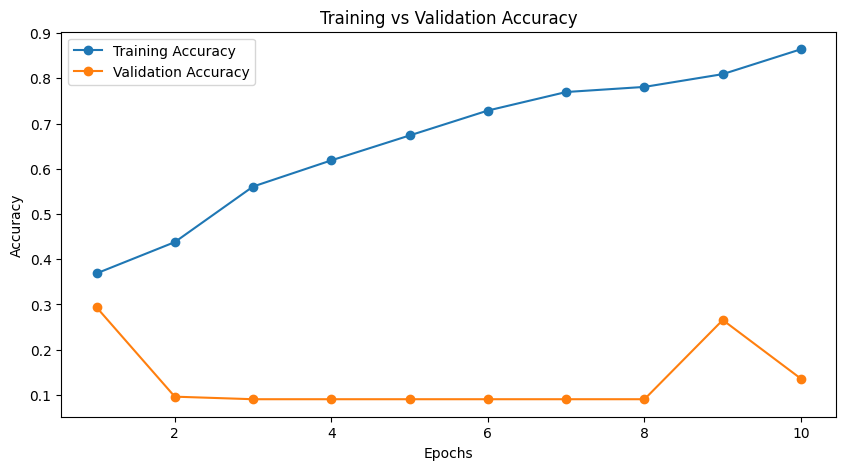

In [27]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Transfer Learning - MobileNetV2

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [31]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    # Optional: add RandomContrast(0.2) if colors vary a lot
])

In [32]:
#MobileNetV2 base model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [33]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [44]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.9195 - loss: 0.2531 - val_accuracy: 0.7119 - val_loss: 0.8709
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 499ms/step - accuracy: 0.9223 - loss: 0.2147 - val_accuracy: 0.7232 - val_loss: 0.8834
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 595ms/step - accuracy: 0.8927 - loss: 0.2811 - val_accuracy: 0.7853 - val_loss: 0.6550
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.9181 - loss: 0.2502 - val_accuracy: 0.7458 - val_loss: 0.8665
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - accuracy: 0.9251 - loss: 0.2345 - val_accuracy: 0.7119 - val_loss: 0.9130
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.9322 - loss: 0.2117 - val_accuracy: 0.6949 - val_loss: 0.9451
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 551ms/step - accuracy: 0.9266 - loss: 0.2239 - val_accuracy: 0.7571 - val_loss: 0.7495
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 460ms/step - accuracy: 0.9266 - loss: 0.2141 - val_accu

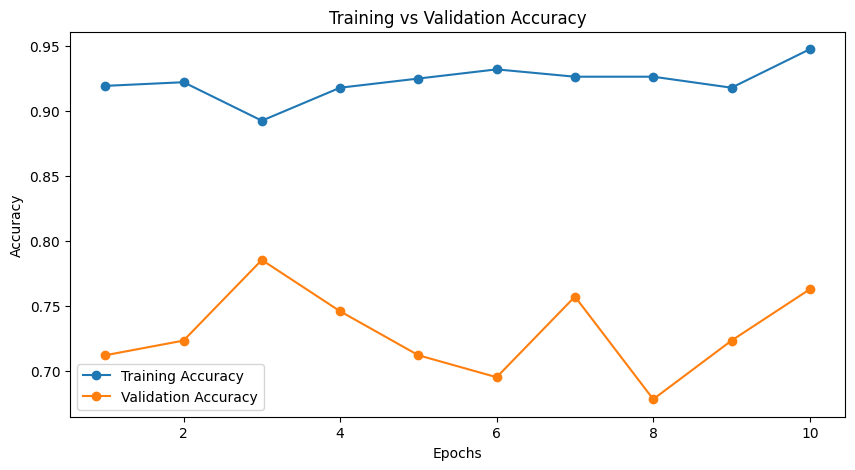

In [45]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [36]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 627ms/step - accuracy: 0.4703 - loss: 1.3892 - val_accuracy: 0.6554 - val_loss: 0.9987
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 450ms/step - accuracy: 0.6667 - loss: 0.8966 - val_accuracy: 0.7232 - val_loss: 0.8656
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 527ms/step - accuracy: 0.7331 - loss: 0.7552 - val_accuracy: 0.7232 - val_loss: 0.8331
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 568ms/step - accuracy: 0.7910 - loss: 0.6228 - val_accuracy: 0.6780 - val_loss: 0.8757
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 456ms/step - accuracy: 0.8164 - loss: 0.5316 - val_accuracy: 0.7119 - val_loss: 0.8801
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 470ms/step - accuracy: 0.7924 - loss: 0.5891 - val_accuracy: 0.7345 - val_loss: 0.8037
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 526ms/step - accuracy: 0.8023 - loss: 0.5481 - val_accuracy: 0.7119 - val_loss: 0.9248
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 548ms/step - accuracy: 0.8263 - loss: 0.4851 - val_accu

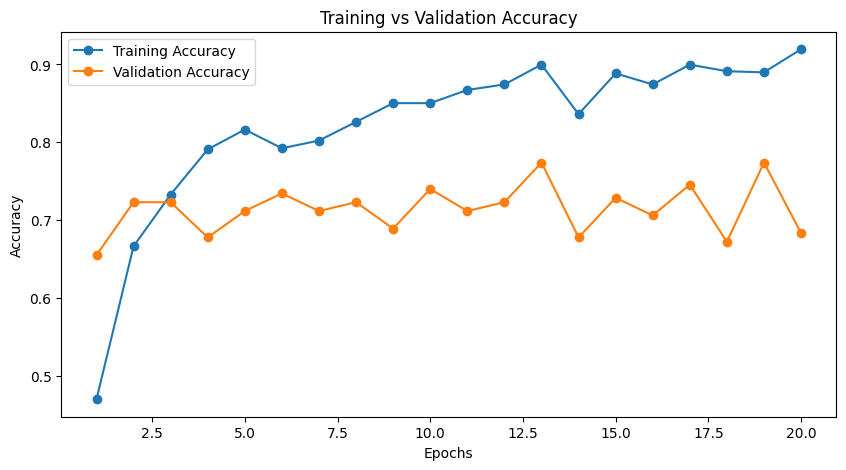

In [41]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [43]:
model.save('/content/drive/MyDrive/Solar_Panel_Dataset/mobilenetv2_2.h5')

## EfficientNet

In [46]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [47]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [48]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [49]:
class_names = train_dataset.class_names

In [50]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [51]:
num_classes = len(class_names)

In [52]:
num_classes

6

In [53]:
class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [54]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [55]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [56]:
train_images = []
train_labels = []

In [57]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [58]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [59]:
validation_images = []
validation_labels = []

In [60]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [61]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [62]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [63]:
base_model.trainable = False

In [64]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [65]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [66]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [67]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 661ms/step - accuracy: 0.4929 - loss: 1.2819 - val_accuracy: 0.6158 - val_loss: 0.9239
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 444ms/step - accuracy: 0.7345 - loss: 0.7440 - val_accuracy: 0.7232 - val_loss: 0.7402
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 533ms/step - accuracy: 0.7980 - loss: 0.5762 - val_accuracy: 0.7119 - val_loss: 0.7374
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 544ms/step - accuracy: 0.8249 - loss: 0.5225 - val_accuracy: 0.7627 - val_loss: 0.7094
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 518ms/step - accuracy: 0.8517 - loss: 0.4563 - val_accuracy: 0.7458 - val_loss: 0.6970
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 529ms/step - accuracy: 0.8814 - loss: 0.3670 - val_accuracy: 0.7684 - val_loss: 0.7001
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - accuracy: 0.8955 - loss: 0.3323 - val_accuracy: 0.7627 - val_loss: 0.6704
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 488ms/step - accuracy: 0.8912 - loss: 0.3070 - val_accu

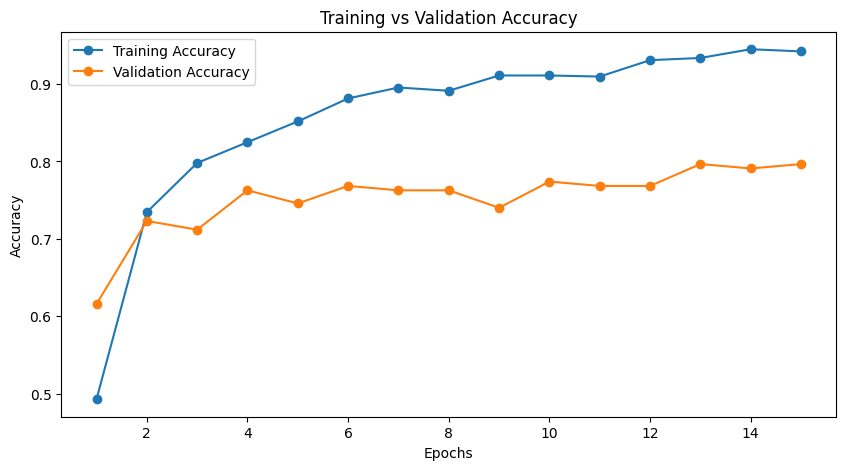

In [68]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 16)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Hyper Parameter Optimization

In [69]:
!pip install keras-tuner  # Run if not installed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.2 MB/s eta 0:00:00


In [70]:
import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [71]:
# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [72]:
# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

In [73]:
# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 02m 54s]
val_accuracy: 0.7683615684509277

Best val_accuracy So Far: 0.8248587846755981
Total elapsed time: 01h 19m 06s
Best hyperparameters:
{'rotation_factor': 0.25, 'zoom_factor': 0.1, 'dropout_rate': 0.1, 'dense_units': 512, 'learning_rate': 0.0007279554359283472}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 423ms/step - accuracy: 0.8249 - loss: 0.6463
Best validation accuracy: 0.8249


In [76]:
best_model.save('/content/drive/MyDrive/Solar_Panel_Dataset/trained_effnet_finetune.h5')

In [77]:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(best_trial.metrics.get_history('accuracy'))       # training accuracy per epoch
print(best_trial.metrics.get_history('val_accuracy'))    # validation accuracy per epoch

[MetricObservation(value=[0.9138417840003967], step=17)]
[MetricObservation(value=[0.8248587846755981], step=17)]
